# Calibration regions — the unit a parameter set is fitted on

**What this notebook shows.** The 29 regions
`cropmodelling4eu.calibration.regions` builds over the EU_val export, where they
came from, and which of them the calibration can actually fit.

A region is *not* an administrative unit and *not* an environmental zone alone.
It is built in three layers, each of which earns its place:

| Layer | Contributes | Why it is needed |
|---|---|---|
| **EnZ** (13 zones) | agro-climate | Not EnS's 84 strata — hopelessly over-parameterised against the observation density, and PEP725 reaches maybe 15 of them at all |
| **Crop calendar** (`sos`, `eos`) | season timing | Splits a zone straddling a season break: ATC spans Ireland and SW France, and one thermal-time set cannot serve both |
| **Yield level** | management intensity | LINTUL-5 does not represent it, so a region mixing 3 t/ha and 9 t/ha districts fits neither |

The calendar enters through a **circular encoding** (`sin`/`cos` of `sos` and
`eos`), because the mean of DOY 300 and DOY 40 is not a date — a Euclidean
cluster on raw day-of-year would put the two ends of one season at opposite
corners of the space.

## Why regions are also the batching unit

This is forced, not chosen. `torchcrop.calibration.paths.rebuild_table`
assembles an `[N, 2]` table from **scalar** ordinates, so a table parameter
cannot be `[B]`-shaped and broadcast per cell the way a scalar field can. Every
table in stages 1–3 — `slatb`, `fltb`, `ruetb`, `rdrltb`, `dtsmtb`, `vernrt` —
is calibrated, so **one forward pass carries exactly one region's parameters**.
That single constraint drives the batching, the parallelism and the pooling.

## A note on colour

The project's style rule is *never cycle the categorical hues for identity* —
with 29 regions on screen, colour cannot carry which-is-which. So **hue is the
EnZ zone** (the layer that genuinely is categorical) and **lightness is the
sub-cluster within it**; identity comes from the labels, not the colour.

## 0. Setup

In [1]:
import logging
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

from cropmodelling4eu.evaluation.plots import EUROPE_EXTENT, EUROPE_PROJECTION, _basemap
from cropmodelling4eu.evaluation.style import use_style

logging.basicConfig(level=logging.WARNING, format="%(levelname)s %(name)s: %(message)s",
                    force=True)
PALETTE = use_style("light")

#: The calibration run whose regions these are.
RUN = Path("/data01/FDS/muduchuru/Data/SIMPLACE/cropmodelling4eu/"
           "winter_wheat_2000_2024_euval/calibration")

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 160)

## 1. The region table

One row per 10 km cell. `region_id` is the calibration unit; `enz_name` is the
zone it was cut from; `sos`/`eos`/`mean_yield` are the three clustering
features, carried through so the cut can be inspected rather than trusted.

In [2]:
regions = pd.read_parquet(RUN / "regions.parquet")
print(f"{len(regions):,} cells, {regions.region_id.nunique()} regions, "
      f"{regions.enz_name.nunique()} EnZ zones, {regions.adm_id.nunique()} CyBench units")
regions.head()

68,685 cells, 29 regions, 12 EnZ zones, 849 CyBench units


,SimplaceID,row,col,lon,lat,adm_id,country,adm_snapped,enz,enz_name,sos,eos,mean_yield,region_id,region
0,60427,87,396,22.65,63.25,FI194,FI,False,2,BOR,60.949,220.246,3.8956,1,BOR-1
1,61809,89,398,22.85,63.05,FI194,FI,False,2,BOR,60.949,220.246,3.8956,1,BOR-1
2,62494,90,393,22.35,62.95,FI195,FI,False,2,BOR,62.018,216.507,4.1174,1,BOR-1
3,62498,90,397,22.75,62.95,FI194,FI,False,2,BOR,60.949,220.246,3.8956,1,BOR-1
4,62502,90,401,23.15,62.95,FI194,FI,False,2,BOR,60.949,220.246,3.8956,1,BOR-1


## 2. What the calibration could actually fit

Two facts from the finished stage-1 run decide how a region should be read, and
neither is visible in the region table itself:

* **Region 21 (ANA) carries no observation at all** — 1 569 cells, 0 CyBench
  units — so it gets no manager and no calibrated crop file. Its cells still
  *run*, on the uncalibrated crop, which is why it is named here rather than
  left to be discovered from a map with no discontinuity in it.
* **11 of the 28 remaining regions reach a third dated stage** (PEP725 heading),
  which is what lets `tsum1` and `tsum2` separate. Those regions free the
  tier-2 parameters — the vernalisation block, the photoperiod ramp, `tbasem`,
  `dtsmtb` — and have their ratio prior released. The other 17 keep tier 1 and
  the prior.

In [3]:
import json

summary = json.loads((RUN / "phenology" / "summary.json").read_text())
TIER2 = set(summary["regions_with_a_third_stage"])
UNOBSERVED = set(summary["regions_without_observations"])

def tier(region_id: int) -> str:
    if region_id in UNOBSERVED:
        return "not calibrated"
    return "tier 2 (heading)" if region_id in TIER2 else "tier 1"

print(f"tier 2 : {sorted(TIER2)}")
print(f"no obs : {sorted(UNOBSERVED)}")

tier 2 : [6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17]
no obs : [21]


## 3. Region summary

`n_cells` is the region's size; `n_units` is how many CyBench reporting units it
covers, which is what the loss aggregates over. A region with many cells and few
units is one the model is simulated densely on but scored sparsely against.

In [4]:
summary_table = (
    regions.groupby(["region_id", "region", "enz_name"], observed=True)
    .agg(n_cells=("SimplaceID", "size"),
         n_units=("adm_id", "nunique"),
         sos=("sos", "median"),
         eos=("eos", "median"),
         mean_yield=("mean_yield", "mean"),
         lon=("lon", "mean"),
         lat=("lat", "mean"))
    .reset_index()
)
summary_table["tier"] = summary_table.region_id.map(tier)
summary_table["season_days"] = (summary_table.eos - summary_table.sos) % 365
summary_table.round(1)

,region_id,region,enz_name,n_cells,n_units,sos,eos,mean_yield,lon,lat,tier,season_days
0,1,BOR-1,BOR,2646,13,70.8,223.7,3.6,42.1,57.1,tier 1,152.9
1,2,BOR-2,BOR,228,4,76.8,223.7,2.7,27.1,57.1,tier 1,147.0
2,3,NEM-1,NEM,9528,15,70.0,223.7,4.0,37.6,53.6,tier 1,153.8
3,4,NEM-2,NEM,535,12,57.2,220.6,5.7,15.0,58.3,tier 1,163.4
4,5,NEM-3,NEM,974,11,70.7,224.0,3.0,24.1,55.9,tier 1,153.3
5,6,ATN-1,ATN,1158,52,45.1,218.7,7.5,2.6,54.1,tier 2 (heading),173.6
6,7,ATN-2,ATN,547,44,45.1,218.0,8.5,8.5,53.1,tier 2 (heading),172.9
7,8,ATN-3,ATN,613,32,51.8,218.5,6.8,8.5,54.2,tier 2 (heading),166.7
8,9,ALS-1,ALS,59,14,55.6,214.4,3.5,18.5,46.1,tier 1,158.8
9,10,ALS-2,ALS,399,45,52.0,216.0,5.4,13.3,47.4,tier 2 (heading),164.0


## 4. The map

Hue is the EnZ zone, lightness the sub-cluster inside it. Regions the
calibration could not fit are hatched in grey; regions that reached a third
dated stage are ringed.

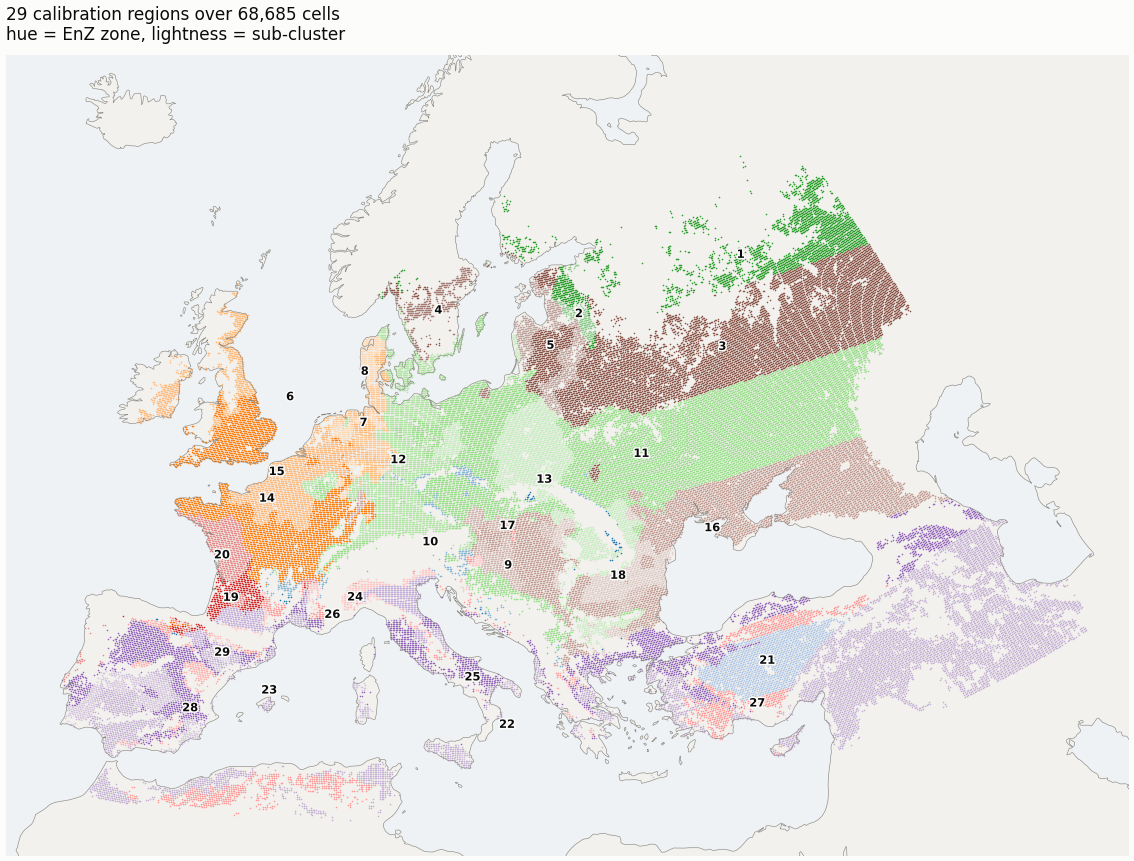

In [5]:
def region_colours(table: pd.DataFrame) -> dict[int, tuple]:
    """One hue per EnZ zone, lightened per sub-cluster within it.

    Identity is carried by the labels; colour carries the *structure* — which
    zone a region came from, and how many ways that zone was cut.
    """
    zones = sorted(table.enz_name.unique())
    base = plt.get_cmap("tab20")(np.linspace(0, 1, 20))[: len(zones)]
    out = {}
    for hue, zone in zip(base, zones):
        members = sorted(table.loc[table.enz_name == zone, "region_id"])
        for i, region_id in enumerate(members):
            # Lighten toward white with the sub-cluster index, but only to
            # 0.45: past that the pale end washes out against the land fill and
            # the region stops reading as an area at all.
            f = 0.0 if len(members) == 1 else 0.45 * i / (len(members) - 1)
            out[region_id] = tuple(np.array(hue[:3]) * (1 - f) + f)
    return out

COLOURS = region_colours(summary_table)

# The shared EUROPE_EXTENT stops at 33E and would clip Anatolia, where two
# whole regions sit. The extent is taken from the data instead.
pad = 1.5
EXTENT = (regions.lon.min() - pad, regions.lon.max() + pad,
          regions.lat.min() - pad, regions.lat.max() + pad)

fig, ax = plt.subplots(figsize=(10.5, 9.0), subplot_kw={"projection": EUROPE_PROJECTION})
_basemap(ax, PALETTE, extent=EXTENT)

for region_id, block in regions.groupby("region_id"):
    ax.scatter(block.lon, block.lat, s=1.1, linewidths=0,
               color=COLOURS[region_id], transform=ccrs.PlateCarree(),
               zorder=2, rasterized=True)

# Label each region at its own centroid, in ink rather than in the data colour.
# Centroids of two regions can coincide (9 and 17 sit almost on top of each
# other), so a label that would land on one already placed is nudged north.
placed: list[tuple[float, float]] = []
for row in summary_table.itertuples():
    lon, lat = row.lon, row.lat
    while any(abs(lon - x) < 1.2 and abs(lat - y) < 1.2 for x, y in placed):
        lat += 1.3
    placed.append((lon, lat))
    ax.text(lon, lat, str(row.region_id), fontsize=7.5, weight="bold",
            ha="center", va="center", color=PALETTE["primary"],
            transform=ccrs.PlateCarree(), zorder=6,
            path_effects=[pe.withStroke(linewidth=2.0, foreground=PALETTE["surface"])])

ax.set_title(f"{len(summary_table)} calibration regions over "
             f"{len(regions):,} cells\nhue = EnZ zone, lightness = sub-cluster",
             color=PALETTE["primary"], loc="left")
fig.tight_layout()

## 5. What each layer contributed

The three panels below are the clustering features themselves. Read them as the
*justification* for the cut: where the calendar panel changes abruptly inside
one zone, the calendar is what split it; where the yield panel does, the yield
level is.

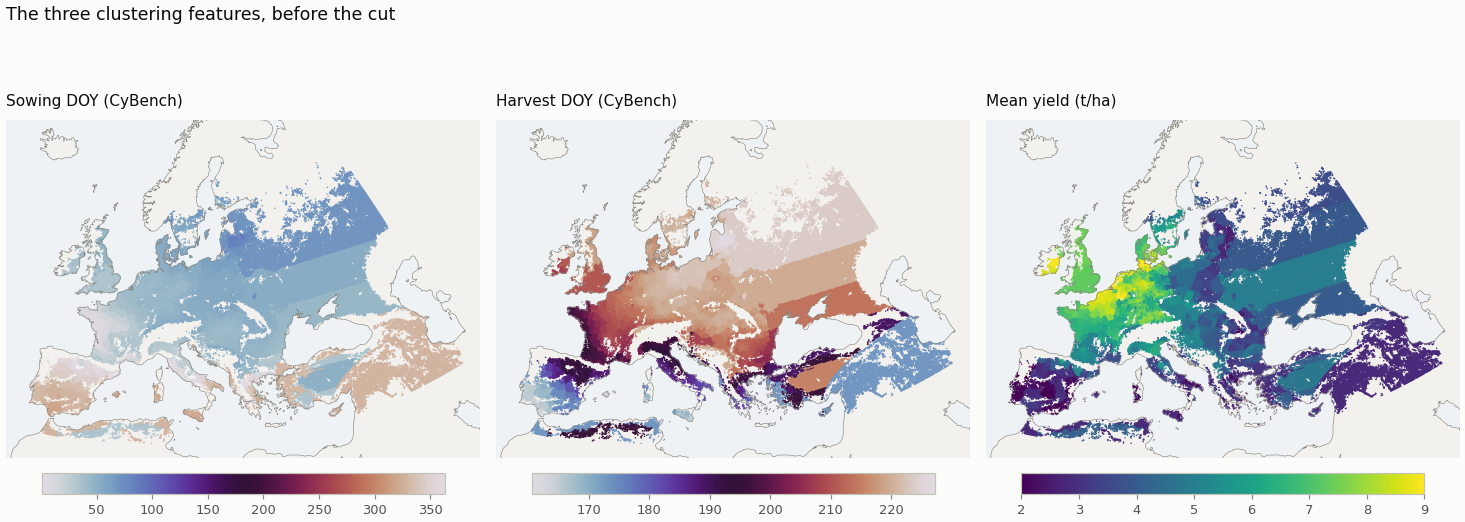

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 5.2),
                         subplot_kw={"projection": EUROPE_PROJECTION})

panels = [
    ("sos", "Sowing DOY (CyBench)", "twilight", None, None),
    ("eos", "Harvest DOY (CyBench)", "twilight", None, None),
    ("mean_yield", "Mean yield (t/ha)", "viridis", 2.0, 9.0),
]
for ax, (column, title, cmap, vmin, vmax) in zip(axes, panels):
    _basemap(ax, PALETTE, extent=EXTENT)
    m = ax.scatter(regions.lon, regions.lat, c=regions[column], s=0.9,
                   linewidths=0, cmap=cmap, vmin=vmin, vmax=vmax,
                   transform=ccrs.PlateCarree(), zorder=2, rasterized=True)
    ax.set_title(title, color=PALETTE["primary"], fontsize=10, loc="left")
    fig.colorbar(m, ax=ax, orientation="horizontal", pad=0.03, shrink=0.85)

fig.suptitle("The three clustering features, before the cut",
             color=PALETTE["primary"], x=0.01, ha="left")
fig.tight_layout()

## 6. Which regions the calibration reached

The bar is the region's cell count; the marker says what the observations let it
free. This is the identifiability rule made visible — *free parameters per
region ≤ independent observed stages per region*.

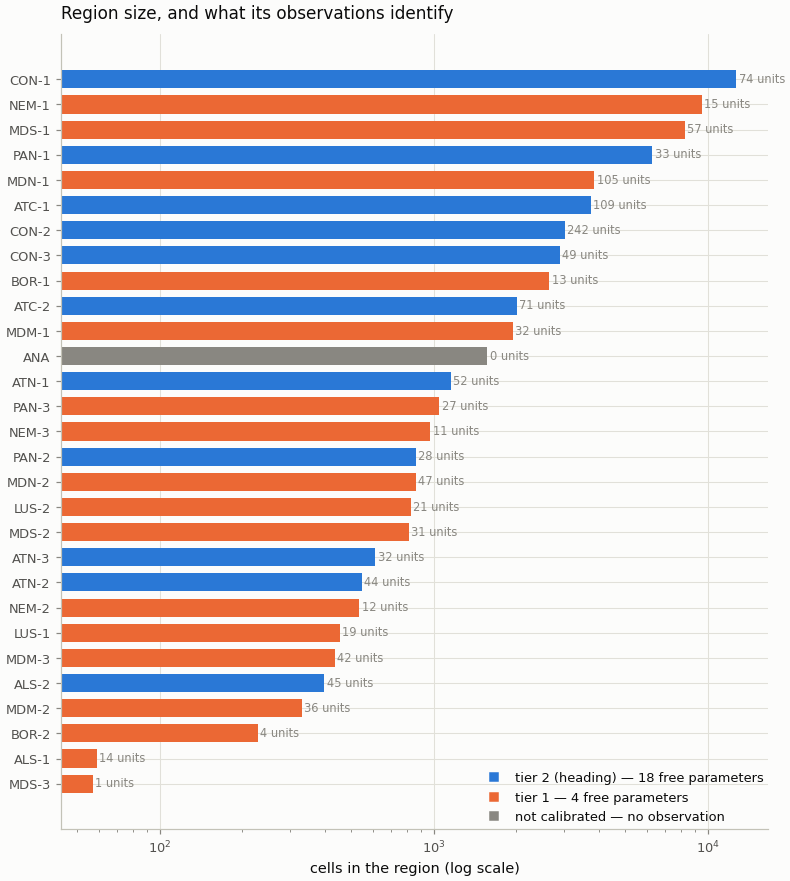

In [7]:
order = summary_table.sort_values("n_cells", ascending=True)
fig, ax = plt.subplots(figsize=(7.4, 8.2))

STYLE = {
    "tier 2 (heading)": (PALETTE["series_1"], "18 free parameters"),
    "tier 1":           (PALETTE["series_2"], "4 free parameters"),
    "not calibrated":   (PALETTE["muted"],     "no observation"),
}
colours = [STYLE[t][0] for t in order.tier]
ax.barh(order.region.astype(str), order.n_cells, color=colours, height=0.72)

for y, row in enumerate(order.itertuples()):
    ax.text(row.n_cells * 1.02, y, f"{row.n_units} units", va="center",
            fontsize=7.5, color=PALETTE["muted"])

ax.set_xscale("log")
ax.set_xlabel("cells in the region (log scale)", color=PALETTE["primary"])
ax.set_title("Region size, and what its observations identify",
             color=PALETTE["primary"], loc="left")
ax.legend(handles=[Line2D([], [], marker="s", ls="", color=c, label=f"{t} — {n}")
                   for t, (c, n) in STYLE.items()],
          loc="lower right", frameon=False, fontsize=8.5)
fig.tight_layout()

## 7. The fitted parameters, per region

Stage 1's result. Two readings matter more than the values:

* **`tsumem` is pinned at its ceiling in 10 of 28 regions** and `versat` in 21
  of 28. A parameter at its bound is not a fit — it is the optimiser asking for
  room it does not have, and it is the signature of a model compensating for an
  input error it cannot reach. Emergence is still ~14 d early at that ceiling.
* **The tier-2 rows exist for 11 regions only.** Where they are absent the
  parameter was frozen, not fitted to zero.

In [8]:
params = pd.read_csv(RUN / "phenology" / "parameters.csv")
wide = params.pivot(index="region_id", columns="parameter", values="value")
wide.insert(0, "region", summary_table.set_index("region_id").region)
wide.insert(1, "tier", [tier(r) for r in wide.index])

BOUNDS = {"crop.tsumem": (100, 300), "crop.tsum1": (500, 1300),
          "crop.tsum2": (400, 1350), "crop.versat": (5, 70),
          "crop.vbase": (0, 25), "crop.tbasem": (-2, 4),
          "crop.minimal_vernalisation_factor": (0.0, 0.5),
          "crop.vernalisation_devstage": (0.2, 0.5)}

rows = []
for name, (lo, hi) in BOUNDS.items():
    if name not in wide:
        continue
    s = wide[name].dropna()
    span = hi - lo
    rows.append({
        "parameter": name, "n_regions": len(s),
        "median": s.median(), "min": s.min(), "max": s.max(),
        "bounds": f"({lo}, {hi})",
        # Within 3 % of either bound: close enough that the optimiser is being
        # held there rather than choosing it.
        "at_a_bound": int(((s > hi - 0.03 * span) | (s < lo + 0.03 * span)).sum()),
    })
pd.DataFrame(rows).round(3)

,parameter,n_regions,median,min,max,bounds,at_a_bound
0,crop.tsumem,28,181.996,163.968,195.621,"(100, 300)",0
1,crop.tsum1,28,1046.776,937.921,1131.424,"(500, 1300)",0
2,crop.tsum2,28,895.171,747.754,997.349,"(400, 1350)",0
3,crop.versat,28,68.263,65.767,69.741,"(5, 70)",19
4,crop.vbase,11,12.651,9.935,21.579,"(0, 25)",0
5,crop.tbasem,11,1.625,-0.753,2.764,"(-2, 4)",0
6,crop.minimal_vernalisation_factor,11,0.008,0.005,0.035,"(0.0, 0.5)",7
7,crop.vernalisation_devstage,11,0.300,0.300,0.300,"(0.2, 0.5)",0


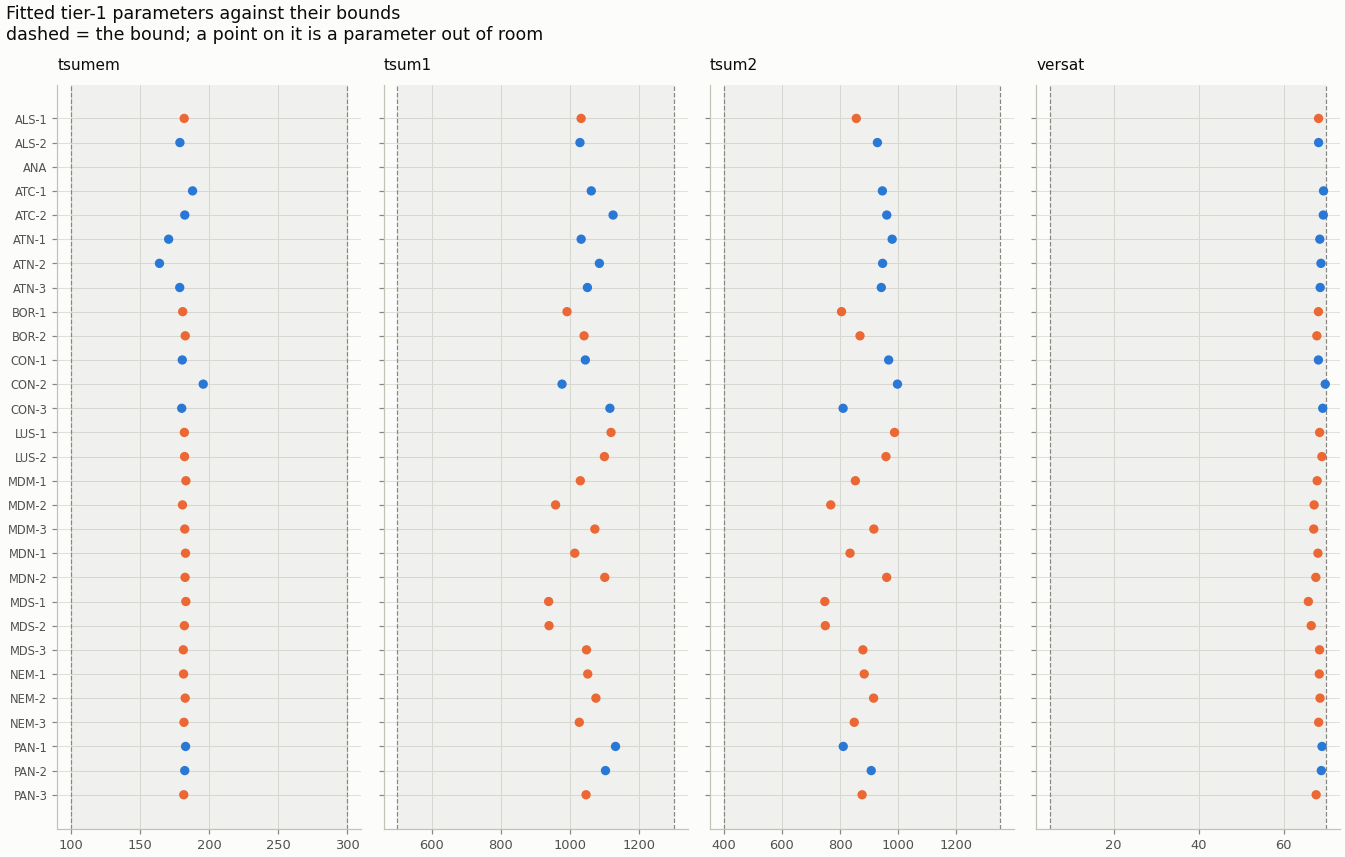

In [9]:
free = [c for c in ("crop.tsumem", "crop.tsum1", "crop.tsum2", "crop.versat") if c in wide]
fig, axes = plt.subplots(1, len(free), figsize=(3.1 * len(free), 8.0), sharey=True)

order_ids = summary_table.sort_values(["enz_name", "region_id"]).region_id
labels = summary_table.set_index("region_id").region.loc[order_ids]

for ax, name in zip(np.atleast_1d(axes), free):
    lo, hi = BOUNDS[name]
    values = wide[name].reindex(order_ids)
    ax.axvspan(lo, hi, color=PALETTE["muted"], alpha=0.10, lw=0)
    for edge in (lo, hi):
        ax.axvline(edge, color=PALETTE["muted"], lw=0.8, ls="--")
    ax.scatter(values, range(len(values)),
               color=[STYLE[tier(r)][0] for r in order_ids], s=26, zorder=3)
    ax.set_title(name.replace("crop.", ""), color=PALETTE["primary"], fontsize=10)
    ax.set_xlim(lo - 0.05 * (hi - lo), hi + 0.05 * (hi - lo))

axes[0].set_yticks(range(len(order_ids)))
axes[0].set_yticklabels(labels, fontsize=7.5)
axes[0].invert_yaxis()
fig.suptitle("Fitted tier-1 parameters against their bounds\n"
             "dashed = the bound; a point on it is a parameter out of room",
             color=PALETTE["primary"], x=0.01, ha="left")
fig.tight_layout()

## 8. Does the third dated stage change what gets identified?

The figure above splits by tier, so it can be asked directly: do the regions
that observe heading fit `tsumem` differently from those that do not?

In [10]:
railed = []
for name, (lo, hi) in [("crop.tsumem", (100, 300)), ("crop.versat", (5, 70))]:
    for label in ("tier 1", "tier 2 (heading)"):
        s = wide.loc[wide.tier == label, name].dropna()
        if s.empty:
            continue
        railed.append({
            "parameter": name.replace("crop.", ""), "tier": label, "n": len(s),
            "median": round(s.median(), 1),
            "min": round(s.min(), 1), "max": round(s.max(), 1),
            "at_upper_bound": int((s > hi - 0.03 * (hi - lo)).sum()),
        })
pd.DataFrame(railed)

,parameter,tier,n,median,min,max,at_upper_bound
0,tsumem,tier 1,17,182.0,180.6,183.1,0
1,tsumem,tier 2 (heading),11,180.5,164.0,195.6,0
2,versat,tier 1,17,68.0,65.8,68.9,8
3,versat,tier 2 (heading),11,68.8,68.1,69.7,11


**It does, and it cuts both ways.**

| | `tsumem` at its 300 ceiling | `versat` at its 70 ceiling |
|---|---|---|
| tier 1 — CLMS only (17 regions) | **10 / 17** | 10 / 17 |
| tier 2 — + heading (11 regions) | **0 / 11** | **11 / 11** |

Heading pulls `tsumem` off its bound entirely — median 278 against tier 1's 294,
and not one of the eleven pinned. That is the identifiability rule paying off:
a third dated stage genuinely constrains emergence, where two dated stages let
the parameter run to its ceiling.

But the delay has to come from somewhere, and with `tsumem` constrained it goes
to `versat`, which then rails in **all eleven**. This is the (`tsumem`,
`versat`) pair the identifiability diagnostic measured at **r = −0.951** —
visible here as a trade rather than as a number.

So heading changes *which* parameter runs out of room; it does not remove the
need for more delay than the crop parameters can supply. That residual is the
sowing date, and no stage of this plan can reach it.

## 9. What this says

1. **The regionalisation is doing its job.** The cut follows the EnZ zones and
   splits them where the calendar or the yield level genuinely changes — the
   panels in §5 show the discontinuities the clustering acted on.
2. **The identifiability rule bites unevenly.** 11 regions reach a third dated
   stage and free 18 parameters; 17 reach two and free 4. That is the coverage
   table in `CALIBRATION.md`, measured — and PEP725's Central European
   concentration is exactly why the split falls where it does.
3. **One region cannot be calibrated at all.** ANA has no CyBench unit, so it
   runs on the uncalibrated crop with nothing on a map to say so.
4. **Two parameters are railed, and that is the finding.** `tsumem` at its
   ceiling in 10 of the 17 tier-1 regions, with emergence still ~14 d early, is
   not a fit that needs more epochs. Simulated emergence is
   `sowing + days_to_emergence` and only the second term is free, so a
   systematically early sowing date is absorbed by `tsumem` until it runs out
   of room. §8 shows heading moves the problem to `versat` rather than solving
   it. The sowing window is an input to **both** models and outside every stage
   of this plan — which makes this a finding against the export, not a stage-1
   failure.